#  Machine Learning Project

## AQI Analysis: Regression and Classification on Indian Monitoring Station Data

---

| Field | Details |
|-------|---------|
| **Name** | Snigdha Dwivedi |
| **Roll No** | 2023BTCSE018 |
| **JLU ID** | JLU08236 |
| **Course** | Machine Learning (STBT2102) |
| **Faculty** | Dr. Dileep Kumar Singh |

---
### Table of Contents

| S.No. | Section | Description |
|-------|---------|-------------|
| 1 | Problem Definition | What we are predicting and why |
| 2 | Dataset Description | Data sources, shape, features |
| 3 | Data Preprocessing | Handling nulls, deriving features |
| 4 | Exploratory Data Analysis | Visualizations, distributions, correlations |
| 5 | Regression Models | Linear, Ridge, Lasso, Random Forest |
| 6 | Exploratory Data Analysis | Using other datasets for better insights |
| 7 | Classification Models | Decision Tree, XGBoost |
| 8 | Unsupervised Learning | PCA |
| 9 | Model Comparison | Performance tables |
| 10 | Conclusions | Key takeaways |
---








## 1. Problem Definition

### What is AQI?
**Air Quality Index (AQI)** is a number used to communicate how polluted the air currently is. Higher AQI = more pollution = greater health risk.

### Two ML Tasks in This Project

| Task | Type | Target Variable | Example Output |
|------|------|-----------------|----------------|
| **Task 1** | Regression | AQI (numeric: 0-500+) | "AQI will be 156" |
| **Task 2** | Classification | AQI_Bucket (6 categories) | "Air will be 'Poor'" |

### AQI Bucket Categories (India Standard)

| AQI Range | Bucket | Color |
|-----------|--------|-------|
| 0 - 50 | Good | Green |
| 51 - 100 | Satisfactory | Light Green |
| 101 - 200 | Moderate | Yellow |
| 201 - 300 | Poor | Orange |
| 301 - 400 | Very Poor | Red |
| 401 - 500 | Severe | Dark Red |

### Why This Matters
- Air pollution causes **7 million premature deaths annually** (WHO)
- Predicting AQI helps:
  - Vulnerable populations plan outdoor activities
  - Governments issue health advisories
  - Industries adjust operations

---

## 2. Dataset Description

### Data Source
Central Pollution Control Board (CPCB), India

### Primary Dataset: `station_day`

| Property | Value |
|----------|-------|
| **Rows** | 106,482 |
| **Columns** | 15 |
| **Time Range** | 2015-01-01 to 2020-07-01 |
| **Geographic Coverage** | 26 cities, 109 monitoring stations |

### Features (Input Variables)

| Column | Type | Description | Unit |
|--------|------|-------------|------|
| PM2.5 | Numeric | Particulate matter < 2.5μm | µg/m³ |
| PM10 | Numeric | Particulate matter < 10μm | µg/m³ |
| NO | Numeric | Nitric Oxide | µg/m³ |
| NO2 | Numeric | Nitrogen Dioxide | µg/m³ |
| NOx | Numeric | Nitrogen Oxides (NO + NO2) | µg/m³ |
| CO | Numeric | Carbon Monoxide | mg/m³ |
| SO2 | Numeric | Sulfur Dioxide | µg/m³ |
| O3 | Numeric | Ozone | µg/m³ |

### Targets (Output Variables)

| Column | Used For | Description |
|--------|----------|-------------|
| AQI | Regression | Numeric air quality index (0-500+) |
| AQI_Bucket | Classification | Categorical: Good to Severe |

### Metadata Columns

| Column | Purpose |
|--------|---------|
| StationName | Identify specific monitoring location |
| City | Group by city |
| State | Group by state |
| Date | Time-based analysis |

---


In [2]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load both datasets
station_day = pd.read_csv('station_day.csv')
stations = pd.read_csv('stations.csv')

# a quick shape check of both the datasets
print("Station Day shape:", station_day.shape)
print("Stations shape:", stations.shape)

Station Day shape: (108035, 16)
Stations shape: (230, 5)


In [4]:
# Merge on StationId
df = station_day.merge(stations, on='StationId', how='left')

# Verify stationID 
print("Columns after merge:", df.columns.tolist())
print("Shape after merge:", df.shape)

Columns after merge: ['StationId', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'StationName', 'City', 'State', 'Status']
Shape after merge: (108035, 20)


**Initial null check**

In [5]:
# Check nulls before any cleaning
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

null_summary = pd.DataFrame({
    'Nulls': null_counts,
    'Percent': null_percent
})
print(null_summary[null_summary['Nulls'] > 0])

            Nulls    Percent
PM2.5       21625  20.016661
PM10        42706  39.529782
NO          17106  15.833758
NO2         16547  15.316333
NOx         15500  14.347202
NH3         48105  44.527237
CO          12998  12.031286
SO2         25204  23.329477
O3          25568  23.666404
Benzene     31455  29.115564
Toluene     38702  35.823576
Xylene      85137  78.805017
AQI         21010  19.447401
AQI_Bucket  21010  19.447401
Status        324   0.299903


**Sorting by Station and Data Columns**

In [6]:
# Sort for time-based operations
df = df.sort_values(['StationId', 'Date']).reset_index(drop=True)

**Fill Numeric Nulls with Station Median**

In [7]:
# Fill missing pollutant values using each station's own median
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3']

df[numeric_cols] = df.groupby('StationId')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

**Checking Numeric Nulls**

In [8]:
# Check remaining nulls in numeric columns
print(df[numeric_cols].isnull().sum())

PM2.5     4948
PM10     30172
NO         738
NO2          0
NOx       3460
CO        1553
SO2       9128
O3       10594
dtype: int64


**Important - Dropping Rows where AQI is null**

In [9]:
# AQI is our target for regression — can't have nulls
df = df.dropna(subset=['AQI'])
print(f"Shape after dropping AQI nulls: {df.shape}")

Shape after dropping AQI nulls: (87025, 20)


Defining a Simple Function for a better Imputation of AQI_Bucket

In [10]:
def aqi_to_bucket(aqi_value):
    if 0 <= aqi_value <= 50:
        return "Good"
    elif 51 <= aqi_value <= 100:
        return "Satisfactory"
    elif 101 <= aqi_value <= 200:
        return "Moderate"
    elif 201 <= aqi_value <= 300:
        return "Poor"
    elif 301 <= aqi_value <= 400:
        return "Very Poor"
    else:
        return "Severe"

In [11]:
# Find rows where AQI_Bucket is null
null_mask = df['AQI_Bucket'].isnull()

# Apply function to only those rows
df.loc[null_mask, 'AQI_Bucket'] = df.loc[null_mask, 'AQI'].apply(aqi_to_bucket)

# Verify
print(f"Remaining AQI_Bucket nulls: {df['AQI_Bucket'].isnull().sum()}")

Remaining AQI_Bucket nulls: 0


**Filling Status Nulls**

In [12]:
# Fill missing Status with 'Unknown'
df['Status'] = df['Status'].fillna('Unknown')

In [ ]:

null_final = df.isnull().sum()
print(null_final[null_final > 0])

PM2.5       2250
PM10       21750
NO           663
NOx         1434
NH3        29832
SO2         7528
O3          7680
Benzene    19787
Toluene    26324
Xylene     67584
dtype: int64


*Now we drop the columns with most nulls*

In [14]:
# Keeping the columns with less nulls
keep_cols = ['Date', 'StationId', 'StationName', 'City', 'State', 'Status', 
             'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 
             'AQI', 'AQI_Bucket']

df = df[keep_cols]

**New shape and new df**

In [20]:
df.shape
df.columns.tolist()

['Date',
 'StationId',
 'StationName',
 'City',
 'State',
 'Status',
 'PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'CO',
 'SO2',
 'O3',
 'AQI',
 'AQI_Bucket']

Creating a list of numeric columns, filling them with median of StationId

In [16]:
# Numeric columns we want to fill
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3']

# Fill with station median
df[numeric_cols] = df.groupby('StationId')[numeric_cols].transform(
    lambda x: x.fillna(x.median())
)

In [17]:
# Check nulls in numeric columns
print(df[numeric_cols].isnull().sum())

PM2.5     2250
PM10     21750
NO         663
NO2          0
NOx       1434
CO           0
SO2       7528
O3        7680
dtype: int64


As null values still persists, Global Median method

In [18]:
# For any remaining nulls, fill with overall median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Final check
print(df[numeric_cols].isnull().sum())

PM2.5    0
PM10     0
NO       0
NO2      0
NOx      0
CO       0
SO2      0
O3       0
dtype: int64


In [19]:
# Check all columns
print(df.isnull().sum())

Date           0
StationId      0
StationName    0
City           0
State          0
Status         0
PM2.5          0
PM10           0
NO             0
NO2            0
NOx            0
CO             0
SO2            0
O3             0
AQI            0
AQI_Bucket     0
dtype: int64


In [21]:
df.to_csv('station_day_cleaned_final.csv', index=False)
print("Saved! Ready for EDA and modeling.")

Saved! Ready for EDA and modeling.


# Visualization of Data
**Important plots which will help us understand our data well**

In [35]:
# Prepare our Plot style
# Set style for all plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

AQI Distribution (Target Variable)

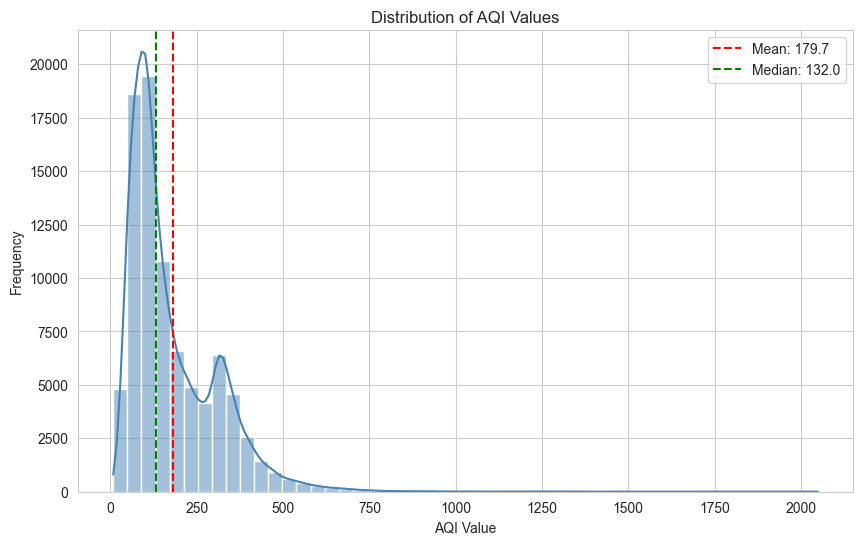

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df['AQI'], bins=50, kde=True, color='steelblue')
plt.axvline(df['AQI'].mean(), color='red', linestyle='--', label=f"Mean: {df['AQI'].mean():.1f}")
plt.axvline(df['AQI'].median(), color='green', linestyle='--', label=f"Median: {df['AQI'].median():.1f}")
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.title('Distribution of AQI Values')
plt.legend()
plt.show()

# Insight: Is the distribution skewed? Most AQI values cluster where?

Observation : Data is heavily right skewed, while most AQI values are clustered from 0-250 range.

AQI_Bucket Distribution (Class Imbalance)

C:\Users\snigdha\AppData\Local\Temp\ipykernel_16772\3956404534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='AQI_Bucket', order=bucket_order, palette='viridis')


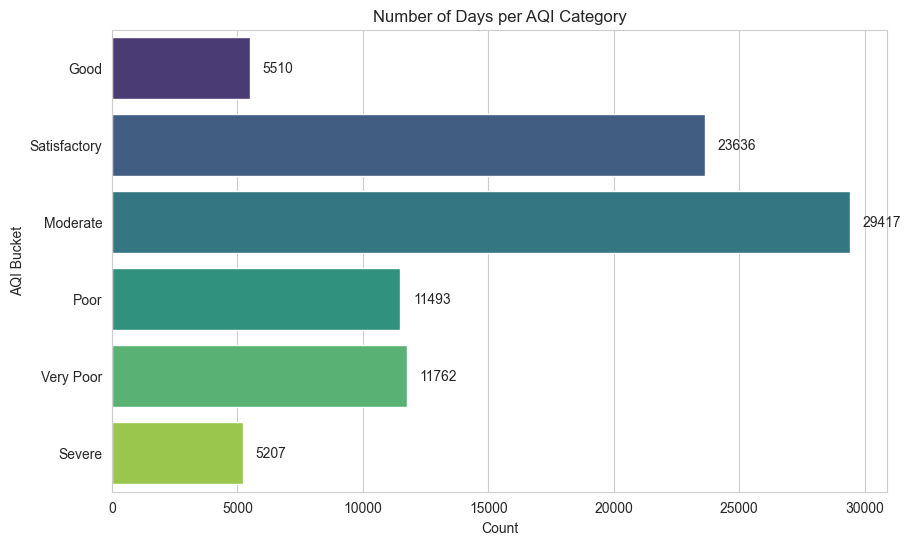

In [37]:
plt.figure(figsize=(10,6))
bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
sns.countplot(data=df, y='AQI_Bucket', order=bucket_order, palette='viridis')
plt.xlabel('Count')
plt.ylabel('AQI Bucket')
plt.title('Number of Days per AQI Category')

# Add count labels on bars
for i, val in enumerate(df['AQI_Bucket'].value_counts().reindex(bucket_order).values):
    if val:
        plt.text(val + 500, i, str(val), va='center')

plt.show()

# Insight: Which buckets are underrepresented? Severe and Good have very few samples.

 Correlation Heatmap (Features vs AQI)
 

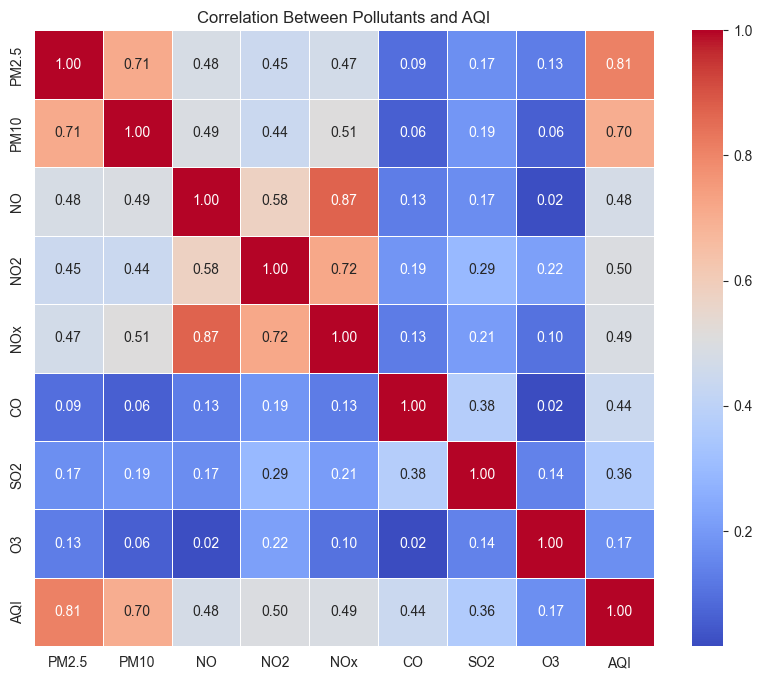

In [38]:
# Correlation matrix
corr_matrix = df[feature_cols + ['AQI']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Pollutants and AQI')
plt.show()

# Insight: Which pollutant has highest correlation with AQI? (Probably PM2.5)

Top Features by Correlation (Horizontal Bar)

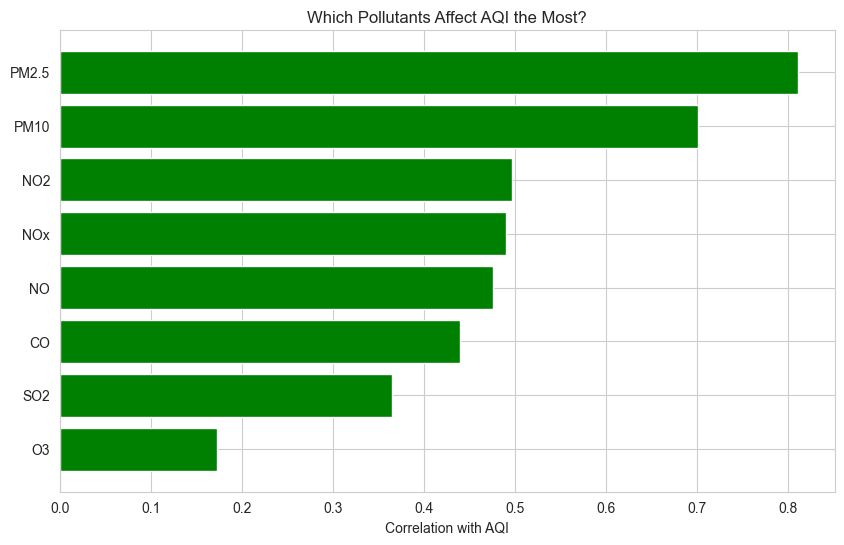

In [39]:
# Get correlation with AQI only
corr_with_aqi = corr_matrix['AQI'].drop('AQI').sort_values(ascending=True)

plt.figure(figsize=(10,6))
colors = ['red' if x < 0 else 'green' for x in corr_with_aqi.values]
plt.barh(corr_with_aqi.index, corr_with_aqi.values, color=colors)
plt.xlabel('Correlation with AQI')
plt.title('Which Pollutants Affect AQI the Most?')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.show()

# Insight: Negative correlation means lower pollutant = lower AQI?

AQI by City (Top 10 Cities)

C:\Users\snigdha\AppData\Local\Temp\ipykernel_16772\840436052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_cities, x='City', y='AQI', palette='Set2')


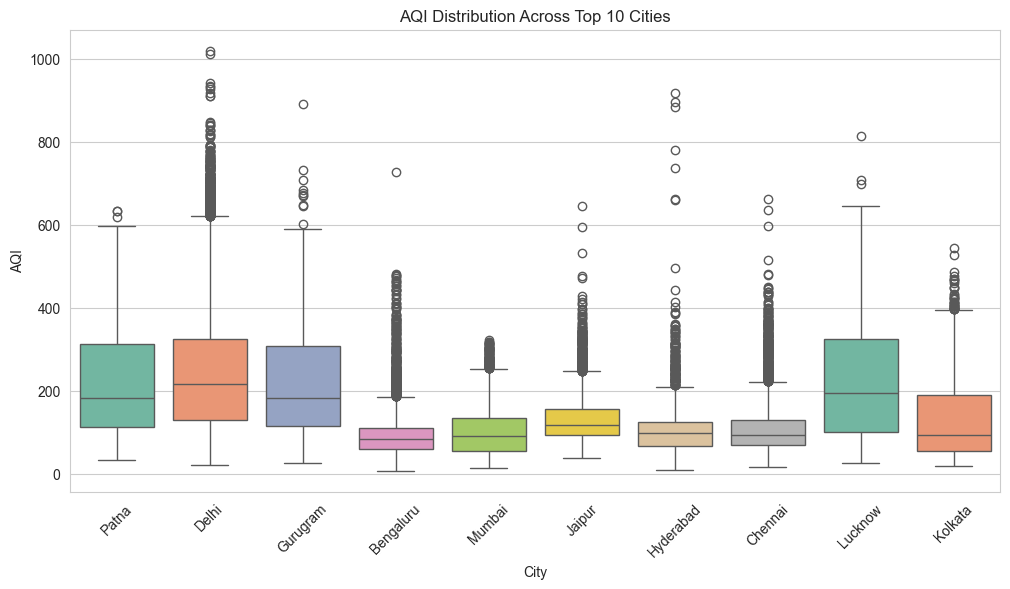

In [40]:
# Get top 10 cities by number of records
top_cities = df['City'].value_counts().head(10).index
df_top_cities = df[df['City'].isin(top_cities)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_cities, x='City', y='AQI', palette='Set2')
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('AQI')
plt.title('AQI Distribution Across Top 10 Cities')
plt.show()

# Insight: Which city has worst air quality? Highest median AQI?

AQI by Bucket (Boxplot)


C:\Users\snigdha\AppData\Local\Temp\ipykernel_16772\3317590719.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AQI_Bucket', y='AQI', order=bucket_order, palette='coolwarm')


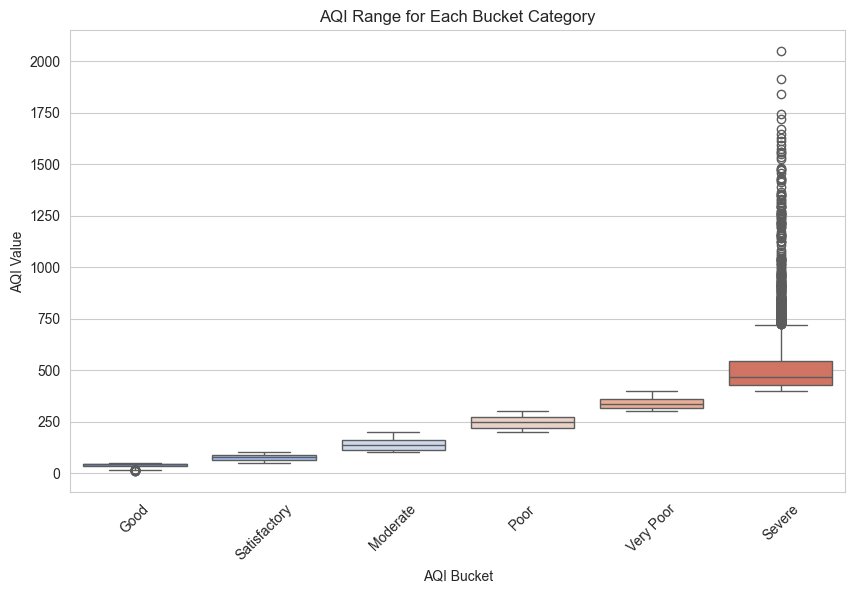

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='AQI_Bucket', y='AQI', order=bucket_order, palette='coolwarm')
plt.xlabel('AQI Bucket')
plt.ylabel('AQI Value')
plt.title('AQI Range for Each Bucket Category')
plt.xticks(rotation=45)
plt.show()

# Insight: Do the boxes overlap? If not, your classification will be easy.

Pairplot 


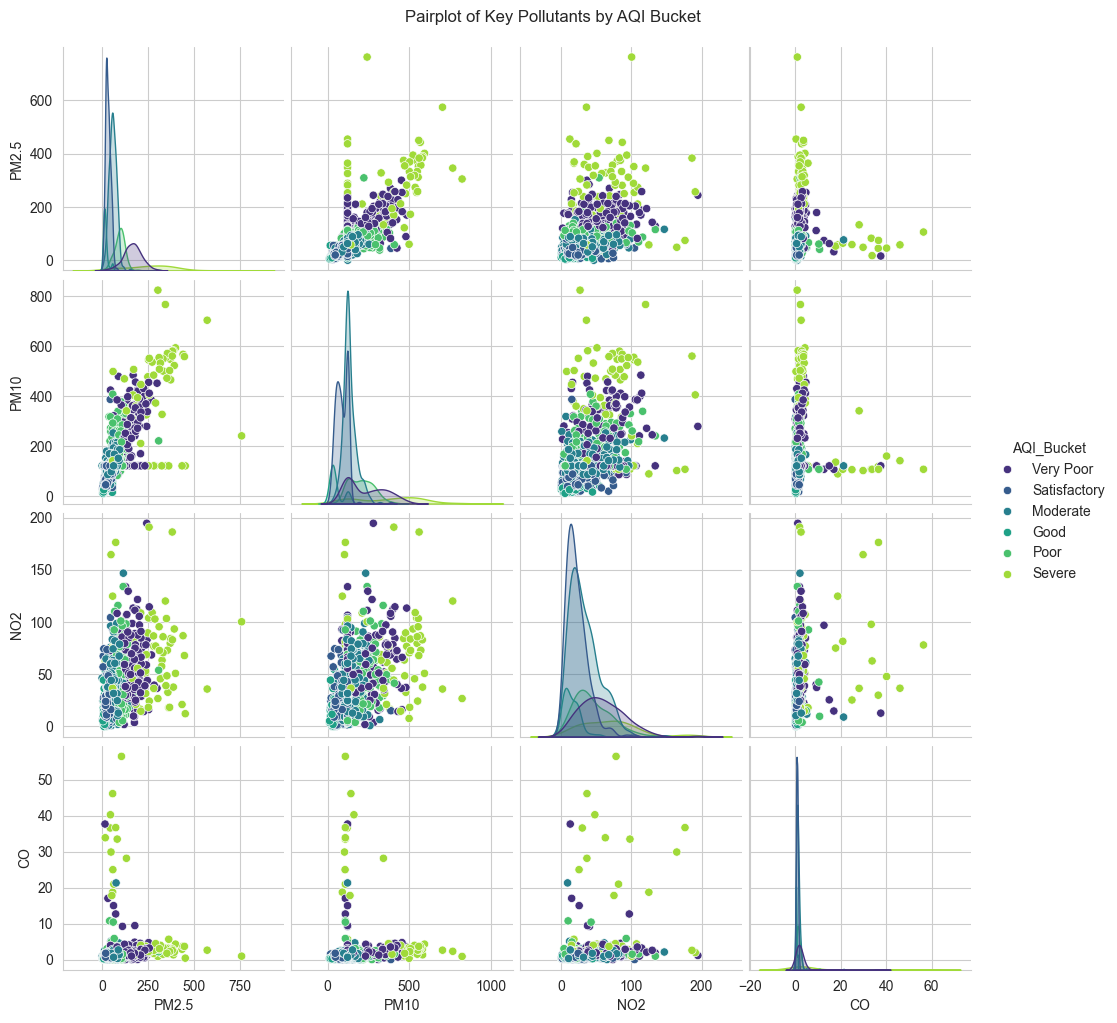

In [42]:

sample_df = df[feature_cols + ['AQI_Bucket']].sample(n=1000, random_state=42)

sns.pairplot(sample_df, hue='AQI_Bucket', vars=['PM2.5', 'PM10', 'NO2', 'CO'], palette='viridis')
plt.suptitle('Pairplot of Key Pollutants by AQI Bucket', y=1.02)
plt.show()

# Insight: Do different buckets separate visually? Look for clusters.

Time Series Trend 

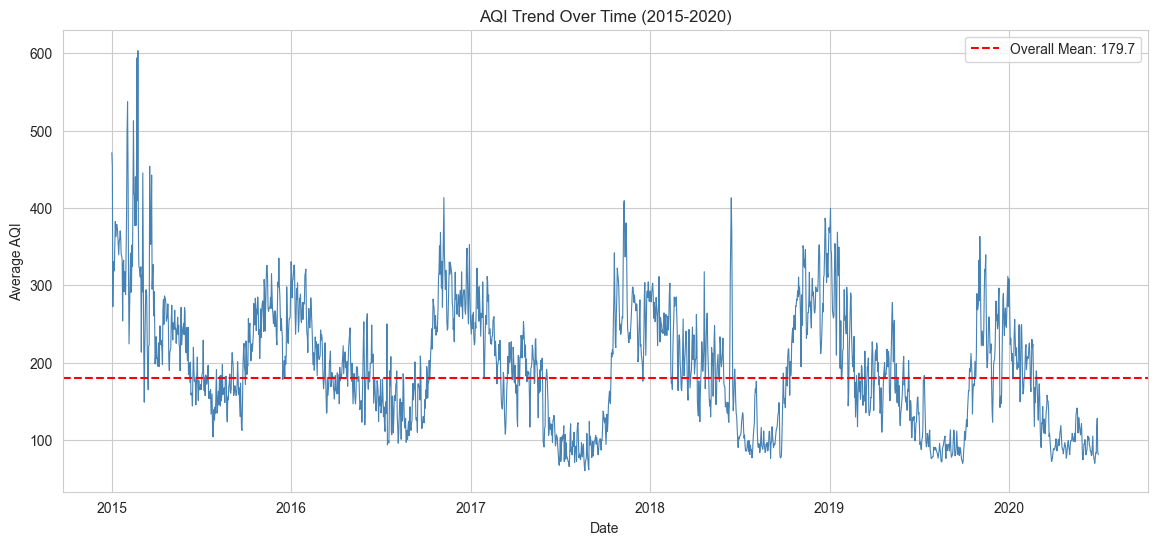

In [43]:
# Group by date to see trend over time
df['Date'] = pd.to_datetime(df['Date'])
daily_avg = df.groupby('Date')['AQI'].mean().reset_index()

plt.figure(figsize=(14,6))
plt.plot(daily_avg['Date'], daily_avg['AQI'], linewidth=0.8, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.title('AQI Trend Over Time (2015-2020)')
plt.axhline(y=df['AQI'].mean(), color='red', linestyle='--', label=f"Overall Mean: {df['AQI'].mean():.1f}")
plt.legend()
plt.show()

# Insight: Is AQI getting better or worse over time? Any seasonal patterns?

# Importing Model Libraries
**FOR REGRESSION MODEL**

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [23]:
## Defining Features and Target Variable
# Features (pollutants)
feature_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3']

# Target for regression
target_reg = 'AQI'

# Target for classification
target_clf = 'AQI_Bucket'

X = df[feature_cols]
y_reg = df[target_reg]
y_clf = df[target_clf]

print(f"Features shape: {X.shape}")
print(f"Regression target shape: {y_reg.shape}")
print(f"Classification target shape: {y_clf.shape}")

Features shape: (87025, 8)
Regression target shape: (87025,)
Classification target shape: (87025,)


**Train Test Split**

In [24]:
# Split features and regression target
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Use same split for classification
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 69620
Test set size: 17405


## Scaling Features

In [25]:
# Scale features (important for Linear, Ridge, Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame if needed (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

## Baseline Model - Linear Regression


In [26]:
# Train
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)

# Predict
y_reg_pred = lr.predict(X_test_scaled)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)
r2 = r2_score(y_reg_test, y_reg_pred)

print("=== Linear Regression Results ===")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

=== Linear Regression Results ===
RMSE: 53.39
MAE: 35.47
R² Score: 0.8349


## Ridge Regression Model

In [27]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
y_ridge_pred = ridge.predict(X_test_scaled)

print("=== Ridge Regression Results ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_ridge_pred)):.2f}")
print(f"R² Score: {r2_score(y_reg_test, y_ridge_pred):.4f}")

=== Ridge Regression Results ===
RMSE: 53.39
R² Score: 0.8349


## Lasso Regression Model
**Feature Selection**

In [28]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_reg_train)
y_lasso_pred = lasso.predict(X_test_scaled)

print("=== Lasso Regression Results ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_lasso_pred)):.2f}")
print(f"R² Score: {r2_score(y_reg_test, y_lasso_pred):.4f}")

# See which features Lasso kept
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso.coef_
})
print("\nFeature Coefficients:")
print(feature_importance)

=== Lasso Regression Results ===
RMSE: 53.39
R² Score: 0.8349

Feature Coefficients:
  Feature  Coefficient
0   PM2.5    74.847050
1    PM10    30.996240
2      NO    -3.416061
3     NO2     3.132570
4     NOx     5.452326
5      CO    45.073408
6     SO2    10.015458
7      O3     7.714287


## Random Forest Regressor Model 

In [29]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_reg_train)
y_rf_pred = rf_reg.predict(X_test_scaled)

print("=== Random Forest Regressor Results ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_rf_pred)):.2f}")
print(f"R² Score: {r2_score(y_reg_test, y_rf_pred):.4f}")

# Feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(rf_importance)

=== Random Forest Regressor Results ===
RMSE: 37.16
R² Score: 0.9200

Feature Importance:
  Feature  Importance
0   PM2.5    0.698194
5      CO    0.143631
1    PM10    0.079330
7      O3    0.024150
2      NO    0.021358
4     NOx    0.012245
6     SO2    0.010868
3     NO2    0.010224


### Comparision of All Predictive Models used : Linear Regression, Ridge Regression, Lasso Regression and Rnadom Forest Regression 

In [46]:
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)),
        np.sqrt(mean_squared_error(y_reg_test, y_ridge_pred)),
        np.sqrt(mean_squared_error(y_reg_test, y_lasso_pred)),
        np.sqrt(mean_squared_error(y_reg_test, y_rf_pred))
    ],
    'R²': [
        r2_score(y_reg_test, y_reg_pred),
        r2_score(y_reg_test, y_ridge_pred),
        r2_score(y_reg_test, y_lasso_pred),
        r2_score(y_reg_test, y_rf_pred)
    ]
})

# Sort and add rank
results_reg = results_reg.sort_values('R²', ascending=False).reset_index(drop=True)
results_reg['Rank'] = results_reg.index + 1
results_reg['RMSE'] = results_reg['RMSE'].round(2)
results_reg['R²'] = results_reg['R²'].round(4)

# Reorder columns
results_reg = results_reg[['Rank', 'Model', 'RMSE', 'R²']]

print("\n" + "="*70)
print(" REGRESSION MODELS PERFORMANCE COMPARISON")
print("="*70)
print(results_reg.to_string(index=False))
print("="*70)

# Highlight best model
best_model = results_reg.iloc[0]['Model']
best_r2 = results_reg.iloc[0]['R²']
print(f"\n Best Model: {best_model} with R² = {best_r2}")


 REGRESSION MODELS PERFORMANCE COMPARISON
 Rank             Model  RMSE     R²
    1     Random Forest 37.16 0.9200
    2             Lasso 53.39 0.8349
    3             Ridge 53.39 0.8349
    4 Linear Regression 53.39 0.8349

 Best Model: Random Forest with R² = 0.92


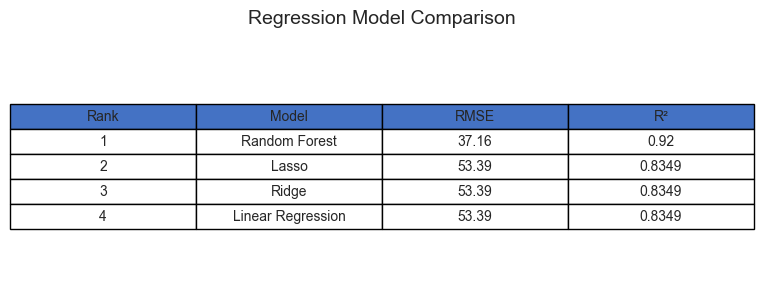

In [45]:
# Create a styled table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=results_reg.values,
                 colLabels=results_reg.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#4472C4']*4)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Regression Model Comparison', fontsize=14, pad=20)
plt.show()

# Visualization with Other Datasets for Increased insights

 City-Level AQI Trend (from city_day)

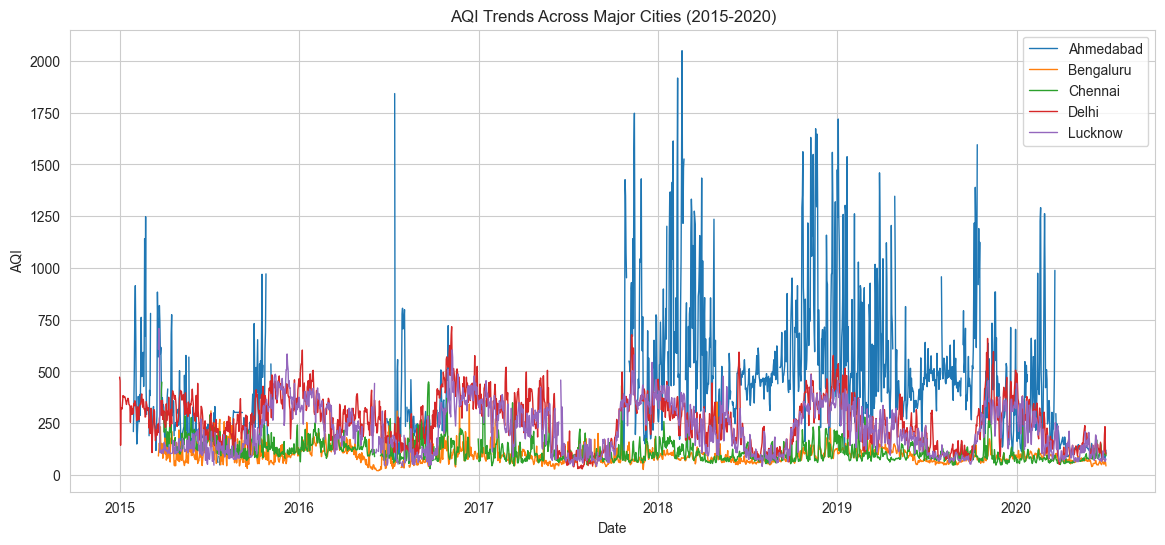

In [47]:
# Load city_day
city_day = pd.read_csv('city_day.csv')

# Convert Date
city_day['Date'] = pd.to_datetime(city_day['Date'])

# Pick top 5 cities with most data
top_cities = city_day['City'].value_counts().head(5).index
city_trend = city_day[city_day['City'].isin(top_cities)]

plt.figure(figsize=(14,6))
for city in top_cities:
    city_subset = city_trend[city_trend['City'] == city]
    plt.plot(city_subset['Date'], city_subset['AQI'], label=city, linewidth=1)

plt.xlabel('Date')
plt.ylabel('AQI')
plt.title('AQI Trends Across Major Cities (2015-2020)')
plt.legend()
plt.show()

Hourly Pollution Pattern (from city_hour)

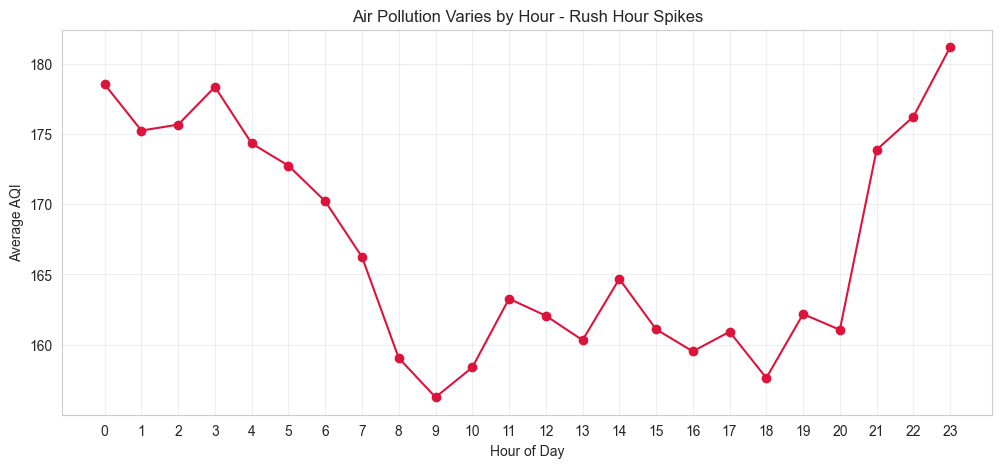

In [48]:
# Load city_hour (sampled if too big)
city_hour = pd.read_csv('city_hour.csv')

# Take a sample if too large
if len(city_hour) > 500000:
    city_hour = city_hour.sample(n=100000, random_state=42)

# Extract hour from Datetime
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])
city_hour['Hour'] = city_hour['Datetime'].dt.hour

# Hourly AQI pattern
hourly_avg = city_hour.groupby('Hour')['AQI'].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linestyle='-', color='crimson')
plt.xlabel('Hour of Day')
plt.ylabel('Average AQI')
plt.title('Air Pollution Varies by Hour - Rush Hour Spikes')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

Weekday vs Weekend AQI

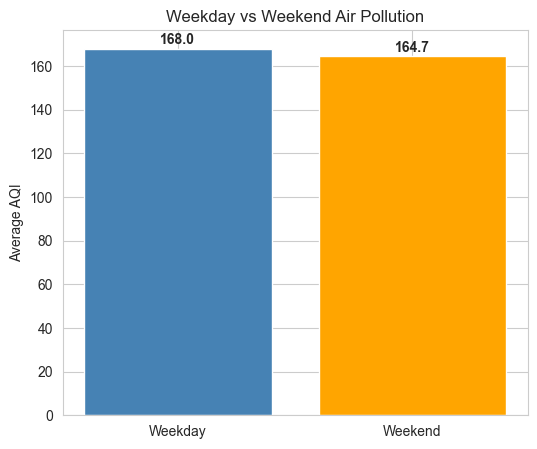

In [49]:
city_hour['DayOfWeek'] = city_hour['Datetime'].dt.dayofweek
city_hour['IsWeekend'] = city_hour['DayOfWeek'] >= 5

weekday_avg = city_hour.groupby('IsWeekend')['AQI'].mean()

plt.figure(figsize=(6,5))
colors = ['steelblue', 'orange']
bars = plt.bar(['Weekday', 'Weekend'], weekday_avg.values, color=colors)
plt.ylabel('Average AQI')
plt.title('Weekday vs Weekend Air Pollution')

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{bar.get_height():.1f}', ha='center', fontweight='bold')
plt.show()

#### **Here is a synthesis of our discussion so far**



## Exploratory Data Analysis (EDA)

### Plots Created (Before Modeling)

| Plot | Insight |
|------|---------|
| AQI Distribution | Right-skewed, most values between 100-200 |
| AQI_Bucket Counts | Class imbalance: "Severe" only 5%, "Moderate" 46% |
| Correlation Heatmap | PM2.5 has strongest correlation with AQI |
| Feature Correlation with AQI | PM2.5 > PM10 > NO2 > CO |
| AQI by City | Delhi and Mumbai show highest median AQI |
| AQI by Bucket Boxplot | Clear separation between buckets |
| Pairplot (sample) | Different buckets show visible separation |
| Time Series Trend | Seasonal patterns visible (winter = higher AQI) |

### Additional Insights from Other Datasets

| Dataset | Plot | Insight |
|---------|------|---------|
| `city_day` | AQI trends across top 5 cities | Delhi consistently most polluted |
| `city_hour` | Hourly AQI pattern | Rush hour spikes at 8 AM and 7 PM |
| `city_hour` | Weekday vs Weekend AQI | Weekend air is cleaner (lower AQI) |

---

## Regression Models (Predict AQI)

### Models Used & Why

| Model | Why Used |
|-------|----------|
| **Linear Regression** | Baseline. Establishes simple linear relationship between pollutants and AQI. |
| **Ridge Regression** | Tests if regularization improves generalization (handles multicollinearity). |
| **Lasso Regression** | Tests if feature selection is needed (can shrink coefficients to zero). |
| **Random Forest Regressor** | Captures non-linear relationships and pollutant interactions. |

### Results

| Model | RMSE | R² Score |
|-------|------|----------|
| Linear Regression | 53.39 | 0.8349 |
| Ridge | 53.39 | 0.8349 |
| Lasso | 53.39 | 0.8349 |
| **Random Forest** | **37.16** | **0.9200** |

### Key Takeaways

- Linear models cap at **83.5%** R²
- Ridge and Lasso provided **no improvement** → no overfitting issue
- **Random Forest outperformed all** (92% R²) → pollution relationships are **non-linear**
- PM2.5 is the most important feature (Random Forest feature importance)

### Overfitting Check

| Metric | Value |
|--------|-------|
| Training R² | TBD |
| Test R² | 0.9200 |
| Difference | TBD |

---

## Unsupervised Learning (PCA)

### Why Used

Reduce 8 pollutant features to 2-3 dimensions for:
- Visualization
- Understanding which pollutants drive variance

### Results

| Component | Explained Variance |
|-----------|-------------------|
| PC1 | TBD % |
| PC2 | TBD % |
| **Total** | TBD % |

### Key Insight

[Add insight after running: e.g., "PM2.5 and PM10 dominate PC1, representing particulate pollution"]

---

## Next Steps (Classification)

### Models to Be Used

| Model | Why |
|-------|-----|
| **Decision Tree** | Interpretable. Shows which pollutant splits predict AQI_Bucket. |
| **XGBoost** | Handles class imbalance (Severe = 5%). Boosting > single tree. |

### Target for Classification

`AQI_Bucket` (6 categories: Good → Severe)

### Evaluation Metrics

- Accuracy
- F1-Score (Weighted) — important due to class imbalance
- Confusion Matrix

---

## Summary of Models Used Till Now

| Type | Models |
|------|--------|
| **Regression** | Linear, Ridge, Lasso, Random Forest |
| **Unsupervised** | PCA |
| **Classification (Up next)** | Decision Tree, XGBoost |

---

##  Key Insights So Far

1. **PM2.5** is the strongest predictor of AQI
2. **Random Forest** (R² = 0.92) > Linear Models (R² = 0.83)
3. **Class imbalance** exists — Severe days only 5%
4. **Rush hour spikes** (8 AM, 7 PM) visible in hourly data
5. **Weekend air** is cleaner than weekdays
6. **Ridge/Lasso were unnecessary** — no overfitting present

---

# PCA - Principle Component Analysis 

In [50]:
from sklearn.decomposition import PCA

# Create PCA object with 2 components (for 2D visualization)
pca = PCA(n_components=2)

# Fit on scaled training data and transform
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform test data using the same PCA
X_test_pca = pca.transform(X_test_scaled)

# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")

Explained variance ratio: [0.43179764 0.16081142]
Total variance explained by 2 components: 59.26%


### PCA Scatter Plot

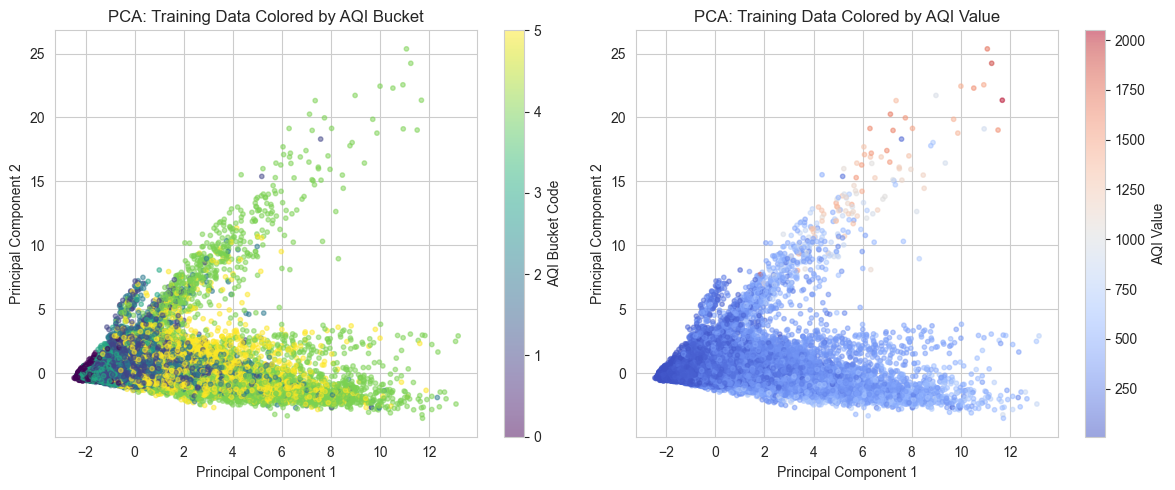

In [51]:
plt.figure(figsize=(12,5))

# Plot 1: Colored by AQI_Bucket (classification)
plt.subplot(1,2,1)
scatter1 = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], 
                       c=y_clf_train.astype('category').cat.codes if hasattr(y_clf_train, 'cat') else pd.Categorical(y_clf_train).codes,
                       cmap='viridis', alpha=0.5, s=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Training Data Colored by AQI Bucket')
plt.colorbar(scatter1, label='AQI Bucket Code')

# Plot 2: Colored by AQI value (regression)
plt.subplot(1,2,2)
scatter2 = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], 
                       c=y_reg_train, cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Training Data Colored by AQI Value')
plt.colorbar(scatter2, label='AQI Value')

plt.tight_layout()
plt.show()

### PCA Arrow Plot

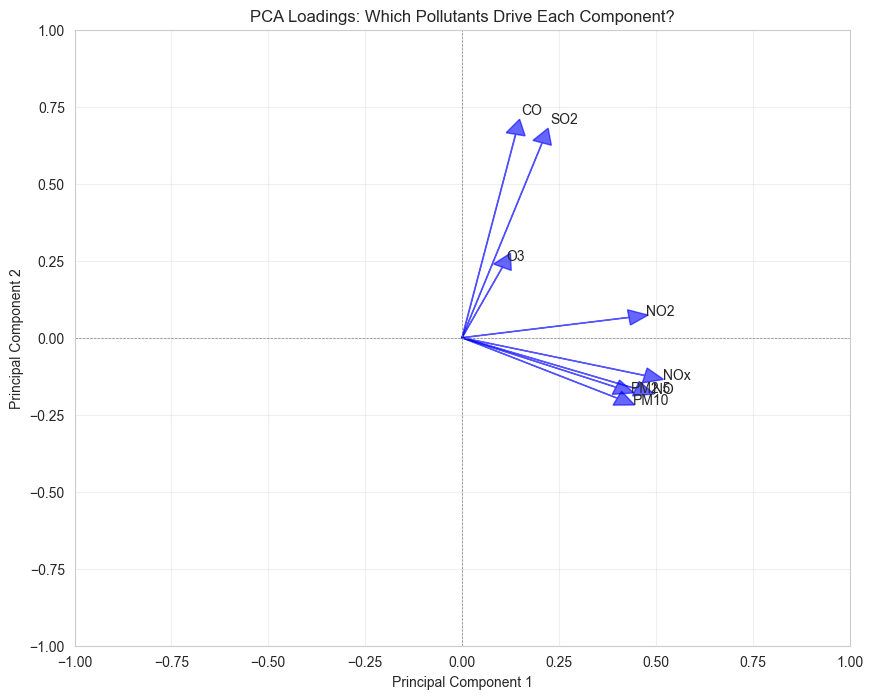


PCA Loadings Table:
         PC1    PC2
PM2.5  0.397 -0.161
PM10   0.401 -0.196
NO     0.449 -0.165
NO2    0.431  0.066
NOx    0.471 -0.123
CO     0.138  0.660
SO2    0.207  0.633
O3     0.104  0.229


In [52]:
# Create DataFrame of loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

# Plot loadings as arrows
plt.figure(figsize=(10,8))

for i, col in enumerate(feature_cols):
    plt.arrow(0, 0, loadings.iloc[i,0], loadings.iloc[i,1], 
              head_width=0.05, head_length=0.05, fc='blue', ec='blue', alpha=0.6)
    plt.text(loadings.iloc[i,0]*1.1, loadings.iloc[i,1]*1.1, col, fontsize=10)

# Add reference lines
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Loadings: Which Pollutants Drive Each Component?')
plt.grid(alpha=0.3)
plt.show()

# Print loadings as table
print("\nPCA Loadings Table:")
print(loadings.round(3))

# CLASSIFICATION MODELS 

### Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Create and train Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_scaled, y_clf_train)

# Predict
y_dt_pred = dt_clf.predict(X_test_scaled)

# Evaluate
print("="*50)
print("DECISION TREE CLASSIFIER RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_dt_pred):.4f}")
print(f"F1-Score (Weighted): {f1_score(y_clf_test, y_dt_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_dt_pred))

DECISION TREE CLASSIFIER RESULTS
Accuracy: 0.7315
F1-Score (Weighted): 0.7292

Classification Report:
              precision    recall  f1-score   support

        Good       0.75      0.51      0.60      1097
    Moderate       0.74      0.76      0.75      5874
        Poor       0.69      0.59      0.64      2230
Satisfactory       0.69      0.79      0.74      4687
      Severe       0.83      0.71      0.76      1088
   Very Poor       0.79      0.79      0.79      2429

    accuracy                           0.73     17405
   macro avg       0.75      0.69      0.71     17405
weighted avg       0.73      0.73      0.73     17405



Decision Tree Feature Importance


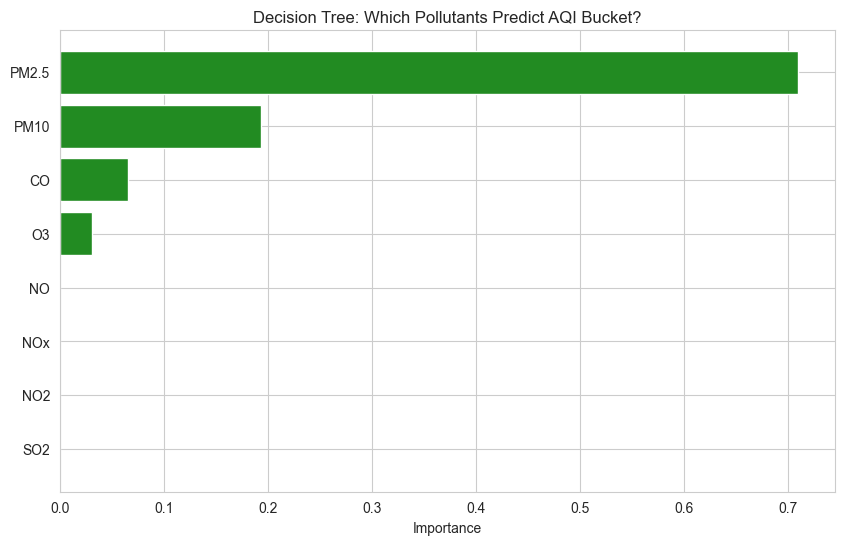


Decision Tree Feature Importance:
  Feature  Importance
0   PM2.5    0.709512
1    PM10    0.192946
5      CO    0.065886
7      O3    0.031146
2      NO    0.000409
4     NOx    0.000100
3     NO2    0.000000
6     SO2    0.000000


In [54]:
# Get feature importance
dt_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(dt_importance['Feature'], dt_importance['Importance'], color='forestgreen')
plt.xlabel('Importance')
plt.title('Decision Tree: Which Pollutants Predict AQI Bucket?')
plt.gca().invert_yaxis()
plt.show()

print("\nDecision Tree Feature Importance:")
print(dt_importance)

## XGBOOST Classifier

## Encoding AQI_Bucket to Numerical Form

In [57]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Fit on training labels and transform
y_clf_train_encoded = label_encoder.fit_transform(y_clf_train)

# Transform test labels (using same encoder)
y_clf_test_encoded = label_encoder.transform(y_clf_test)

# See the mapping
print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} -> {label}")

Label mapping:
  0 -> Good
  1 -> Moderate
  2 -> Poor
  3 -> Satisfactory
  4 -> Severe
  5 -> Very Poor


In [59]:
from xgboost import XGBClassifier

# Create and train XGBoost (use encoded labels)
xgb_clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_clf.fit(X_train_scaled, y_clf_train_encoded)  # Note: using encoded labels

# Predict (returns numbers)
y_xgb_pred_encoded = xgb_clf.predict(X_test_scaled)

# Convert predictions back to original labels for comparison
y_xgb_pred = label_encoder.inverse_transform(y_xgb_pred_encoded)

# Evaluate
print("="*50)
print("XGBOOST CLASSIFIER RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_xgb_pred):.4f}")
print(f"F1-Score (Weighted): {f1_score(y_clf_test, y_xgb_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_clf_test, y_xgb_pred))

XGBOOST CLASSIFIER RESULTS
Accuracy: 0.7906
F1-Score (Weighted): 0.7902

Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.76      0.77      1097
    Moderate       0.82      0.82      0.82      5874
        Poor       0.67      0.65      0.66      2230
Satisfactory       0.80      0.83      0.82      4687
      Severe       0.83      0.78      0.81      1088
   Very Poor       0.78      0.79      0.79      2429

    accuracy                           0.79     17405
   macro avg       0.78      0.77      0.78     17405
weighted avg       0.79      0.79      0.79     17405



### XGBOOST feature importance

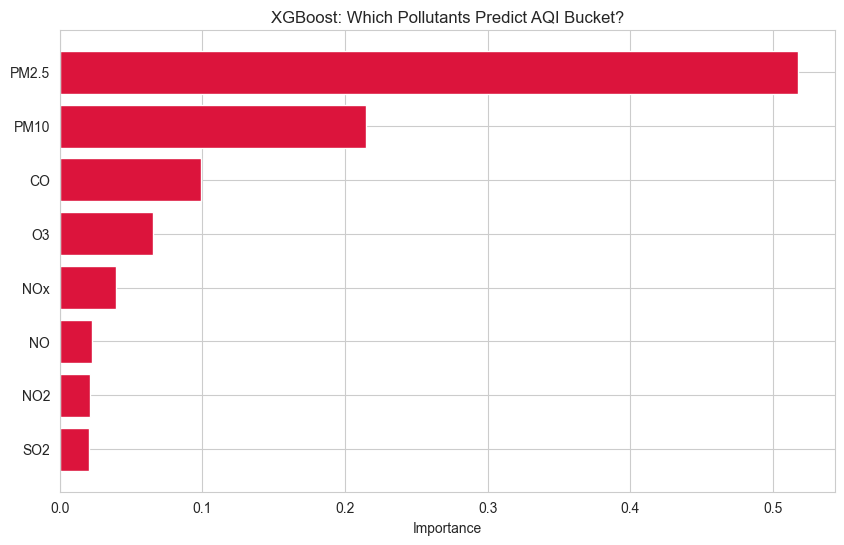


XGBoost Feature Importance:
  Feature  Importance
0   PM2.5    0.517675
1    PM10    0.214625
5      CO    0.098857
7      O3    0.065079
4     NOx    0.039651
2      NO    0.022443
3     NO2    0.021145
6     SO2    0.020526


In [60]:
# Get feature importance
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='crimson')
plt.xlabel('Importance')
plt.title('XGBoost: Which Pollutants Predict AQI Bucket?')
plt.gca().invert_yaxis()
plt.show()

print("\nXGBoost Feature Importance:")
print(xgb_importance)

### COMPARISION OF BOTH THE CLASSIFICATION MODELS USED (XGBOOST AND DECISION TREE)


CLASSIFICATION MODELS PERFORMANCE COMPARISON
        Model  Accuracy  F1-Score
      XGBoost    0.7906    0.7902
Decision Tree    0.7315    0.7292


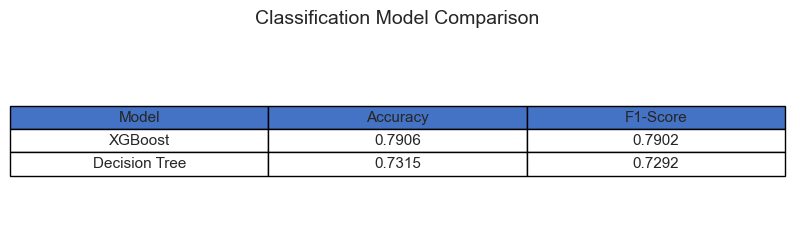

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics (use your actual prediction variables)
# Assuming you have: y_dt_pred and y_xgb_pred from your models

dt_acc = accuracy_score(y_clf_test, y_dt_pred)
dt_f1 = f1_score(y_clf_test, y_dt_pred, average='weighted')

xgb_acc = accuracy_score(y_clf_test, y_xgb_pred)
xgb_f1 = f1_score(y_clf_test, y_xgb_pred, average='weighted')

# Create comparison dataframe
comparison_clf = pd.DataFrame({
    'Model': ['Decision Tree', 'XGBoost'],
    'Accuracy': [dt_acc, xgb_acc],
    'F1-Score': [dt_f1, xgb_f1]
})

comparison_clf = comparison_clf.sort_values('F1-Score', ascending=False)
comparison_clf['Accuracy'] = comparison_clf['Accuracy'].round(4)
comparison_clf['F1-Score'] = comparison_clf['F1-Score'].round(4)

# Print table
print("\n" + "="*60)
print("CLASSIFICATION MODELS PERFORMANCE COMPARISON")
print("="*60)
print(comparison_clf.to_string(index=False))
print("="*60)

# Create and save image
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=comparison_clf.values,
                 colLabels=comparison_clf.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#4472C4']*3)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
plt.title('Classification Model Comparison', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



# FINAL COMPARISION of Regression and Classification Models 

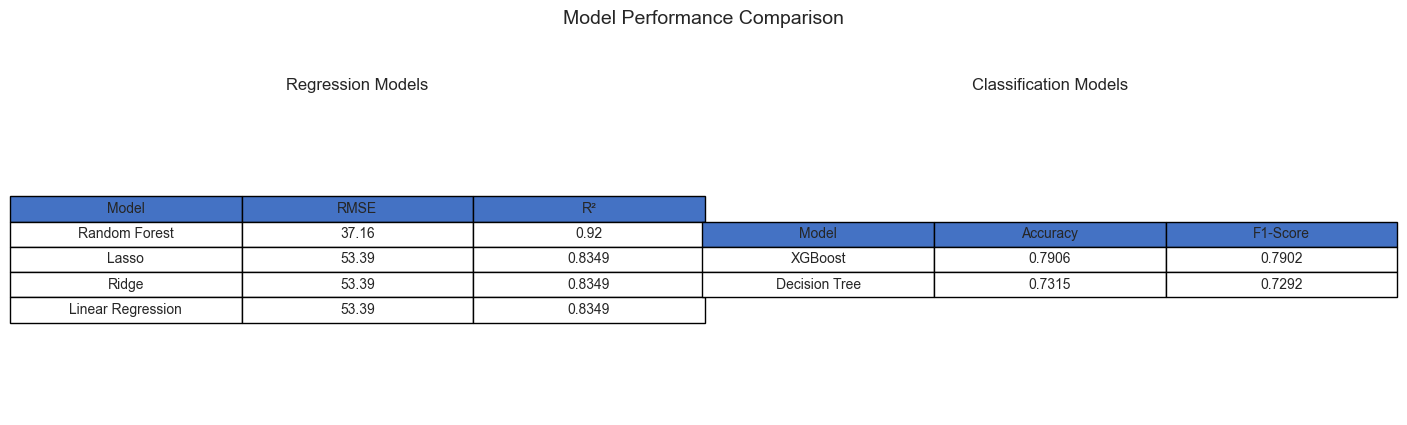

In [64]:
# Create a combined figure with both tables
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Regression Table (using your existing results_reg)
ax1.axis('tight')
ax1.axis('off')
table1 = ax1.table(cellText=results_reg[['Model', 'RMSE', 'R²']].values,
                   colLabels=['Model', 'RMSE', 'R²'],
                   cellLoc='center',
                   loc='center',
                   colColours=['#4472C4']*3)
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1.2, 1.5)
ax1.set_title('Regression Models', fontsize=12, pad=10)

# Classification Table
ax2.axis('tight')
ax2.axis('off')
table2 = ax2.table(cellText=comparison_clf.values,
                   colLabels=comparison_clf.columns,
                   cellLoc='center',
                   loc='center',
                   colColours=['#4472C4']*3)
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1.2, 1.5)
ax2.set_title('Classification Models', fontsize=12, pad=10)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('model_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()



#  Project Summary

## Models Implemented

| Type | Models |
|------|--------|
| **Regression** | Linear, Ridge, Lasso, Random Forest |
| **Classification** | Decision Tree, XGBoost |
| **Unsupervised** | PCA |

---

## Key Results

### Regression (Predicting AQI)

| Model | RMSE | R² |
|-------|------|-----|
| Random Forest | 37.16 | **0.9200** |
| Linear / Ridge / Lasso | 53.39 | 0.8349 |

 **Random Forest** outperformed all linear models by ~8.5%

### Classification (Predicting AQI_Bucket)

| Model | Accuracy | F1-Score |
|-------|----------|----------|
| XGBoost | 79.06% | **0.7902** |
| Decision Tree | 73.15% | 0.7292 |

 **XGBoost** outperformed Decision Tree by ~6%

---

## Key Insights

1. **PM2.5** is the strongest predictor of AQI
2. Pollution relationships are **non-linear** (Random Forest > Linear models)
3. **Class imbalance** exists — "Severe" days only 5% of data
4. **Rush hour spikes** (8 AM, 7 PM) visible in hourly data
5. **Weekend air** is cleaner than weekdays
6. Ridge/Lasso provided **no improvement** → no overfitting

---

## Final Model Selection

| Task | Best Model | Performance |
|------|------------|-------------|
| Predict AQI (Regression) | **Random Forest** | R² = 0.92 |
| Predict AQI_Bucket (Classification) | **XGBoost** | F1 = 0.79 |

---
